# scRNA-seq Analysis: PBMC 3k
## A complete single-cell RNA sequencing pipeline using Scanpy

This notebook walks through quality control, normalization, dimensionality 
reduction, clustering, and cell type annotation of 3,000 human peripheral 
blood mononuclear cells (PBMCs) from 10x Genomics.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sc.settings.verbosity = 1 ## min output msgs
sc.settings.figdir = '../figures/'
%matplotlib inline

## Step 1: Load Data

In [4]:
adata = sc.datasets.pbmc3k()
print(adata)

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


## Step 2: Quality Control

In [15]:
adata.var

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180


In [17]:
adata.var_names

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10',
       ...
       'KIR3DL2-1', 'AL590523.1', 'CT476828.1', 'PNRC2-1', 'SRSF10-1',
       'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1'],
      dtype='object', name='index', length=32738)

In [27]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

In [39]:
mt_genes = adata.var['mt'].sum()

In [45]:
print(f"The number of mitochondrial genes in this set is {mt_genes}")

The number of mitochondrial genes in this set is 13


In [47]:
adata.var[adata.var['mt']==True]

,gene_ids,mt
index,,
MT-ND1,ENSG00000198888,True
MT-ND2,ENSG00000198763,True
MT-CO1,ENSG00000198804,True
MT-CO2,ENSG00000198712,True
MT-ATP8,ENSG00000228253,True
MT-ATP6,ENSG00000198899,True
MT-CO3,ENSG00000198938,True
MT-ND3,ENSG00000198840,True
MT-ND4L,ENSG00000212907,True


In [51]:
sc.pp.calculate_qc_metrics(adata, qc_vars = ['mt'], percent_top = None, log1p = False, inplace = True)

In [53]:
adata.obs.head()

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
index,,,,
AAACATACAACCAC-1,781,2421.0,73.0,3.015283
AAACATTGAGCTAC-1,1352,4903.0,186.0,3.793596
AAACATTGATCAGC-1,1131,3149.0,28.0,0.889171
AAACCGTGCTTCCG-1,960,2639.0,46.0,1.743085
AAACCGTGTATGCG-1,522,981.0,12.0,1.223242


### QC Visualization

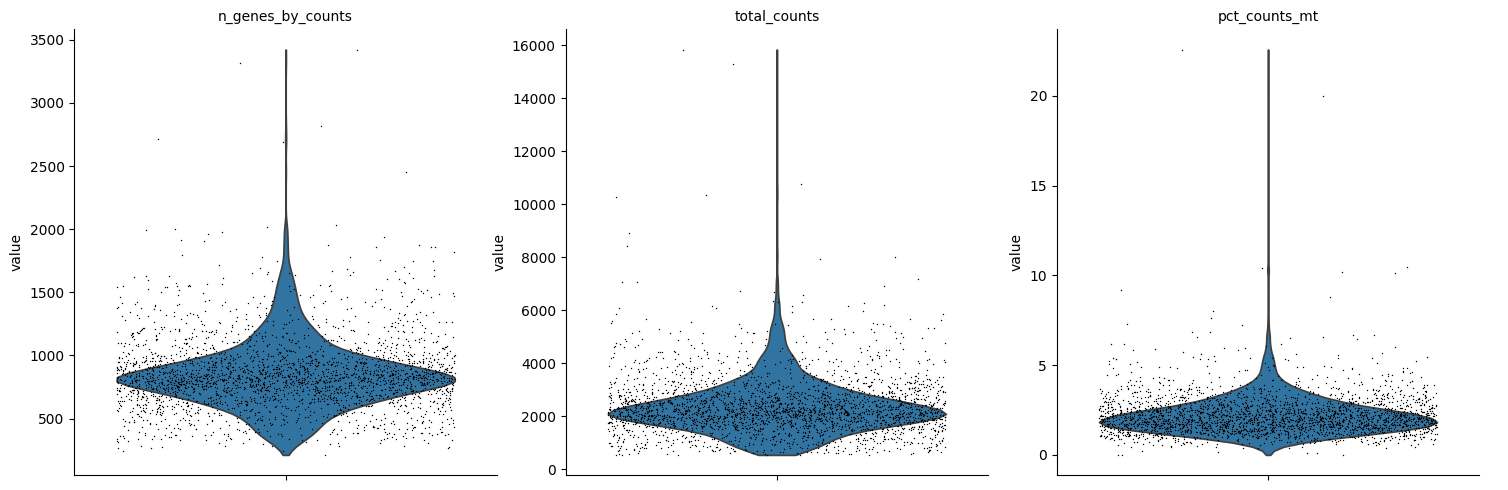

In [72]:
sc.pl.violin(
    adata,
    keys = ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter = 0.4,
    multi_panel = True
)

### QC Observations

**n_genes_by_counts**
- Most cells have between 500-1000 genes detected
- Cells with very few genes (<200) are likely empty droplets
- Cells with very high genes (>2500) are likely doublets — two cells captured together

**total_counts**
- Most cells have 1500-2500 RNA molecules
- Cells with 7000-16000 counts are suspicious — likely doublets

**pct_counts_mt**
- Most cells have 2-3% mitochondrial RNA — this is normal
- Cells above 5% are likely dying or damaged — they leak regular RNA 
  but retain mitochondrial RNA longer

**Thresholds chosen:**
- Keep cells with n_genes between 200 and 2500
- Keep cells with pct_counts_mt below 5%

Note: These thresholds are not universal facts — they are conventions 
based on this dataset. Different tissues or experiments may require 
different cutoffs.|

In [75]:
print(f"Cells before filtering: {adata.n_obs}")

Cells before filtering: 2700


In [82]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"Cells after filtering: {adata.n_obs}")

Cells after filtering: 2638


### Filtering Results

- Started with 2,700 cells
- Removed cells with fewer than 200 genes (empty droplets)
- Removed cells with more than 2,500 genes (doublets)
- Removed cells with more than 5% mitochondrial RNA (dying cells)
- Removed genes detected in fewer than 3 cells (rare/noisy genes)
- **Retained 2,638 high-quality cells for downstream analysis**

In [85]:
adata.obs

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_genes
index,,,,,
AAACATACAACCAC-1,781,2421.0,73.0,3.015283,781
AAACATTGAGCTAC-1,1352,4903.0,186.0,3.793596,1352
AAACATTGATCAGC-1,1131,3149.0,28.0,0.889171,1131
AAACCGTGCTTCCG-1,960,2639.0,46.0,1.743085,960
AAACCGTGTATGCG-1,522,981.0,12.0,1.223242,522
...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,3461.0,73.0,2.109217,1155
TTTCTACTGAGGCA-1,1227,3447.0,32.0,0.928343,1227
TTTCTACTTCCTCG-1,622,1684.0,37.0,2.197150,622


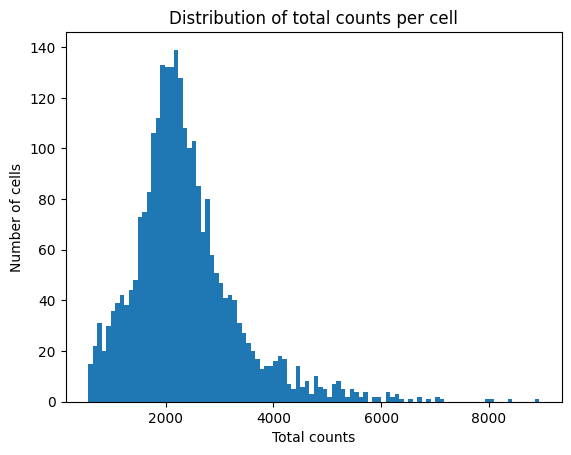

In [87]:
plt.hist(adata.obs['total_counts'], bins=100)
plt.xlabel('Total counts of RNA molecules')
plt.ylabel('Number of cells')
plt.title('Distribution of total counts of RNA molecules per cell')
plt.show()

## Step 3: Normalization

In [96]:
import warnings
warnings.filterwarnings("ignore")

In [90]:
sc.pp.normalize_total(adata, target_sum=1e4)

/var/folders/rt/zp8d7lq91r96q85g60t291m00000gn/T/ipykernel_78804/3661531845.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [92]:
sc.pp.log1p(adata)

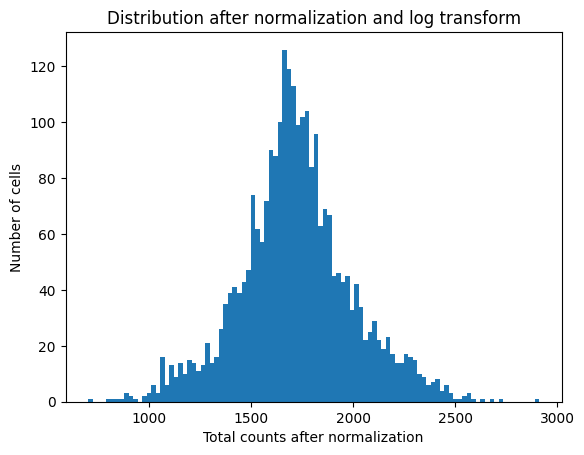

In [98]:
plt.hist(adata.X.sum(axis=1), bins=100)
plt.xlabel('Total counts after normalization')
plt.ylabel('Number of cells')
plt.title('Distribution after normalization and log transform')
plt.show()

### Normalization observations

**Before normalization:**
- Cells had different total counts ranging from 1000 to 8000

**After normalization:**
- Every cell scaled to 10,000 total counts
- Low count cells scaled up, high count cells scaled down

**Log transformation:**
- Gene counts are heavily skewed — some genes have 5 counts, others 5000
- Log1p compresses this scale making the data more uniform

## Step 4: Feature Selection — Highly Variable Genes

In [103]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f"Highly variable genes: {adata.var.highly_variable.sum()}")

Highly variable genes: 1838


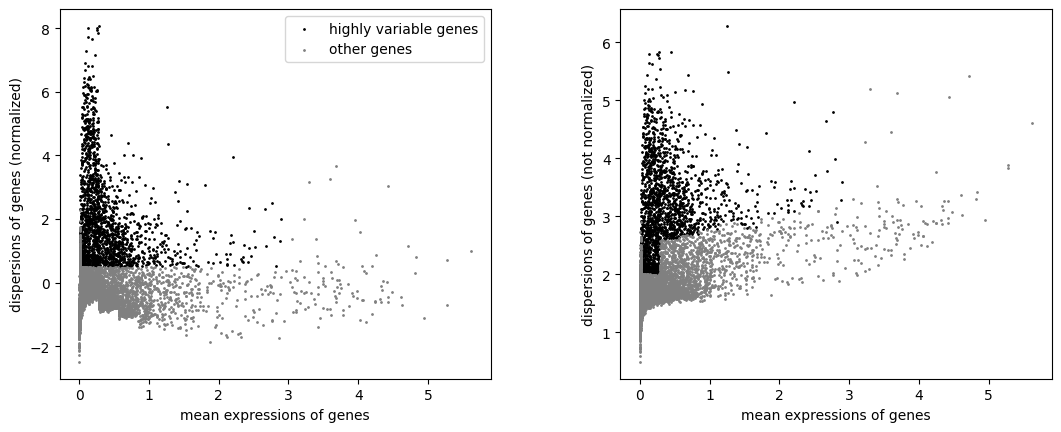

In [105]:
sc.pl.highly_variable_genes(adata)

**What are highly variable genes?**
Genes that are expressed differently across cells; high in some, low in others. These are the most informative genes for telling cell types apart.

**Why 1,838 out of 33,000?**
Not all genes are useful. We filtered out:
- Genes expressed in almost no cells (too rare; likely noise)
- Genes expressed the same in every cell (housekeeping genes — no information)
- Only kept genes that vary enough across cells to be meaningful

**What the plot showed:**
- Black dots = 1,838 highly variable genes → kept for analysis
- Gray dots = remaining ~31,000 genes → discarded
- Selection criteria: reasonable mean expression AND high dispersion

## Step 5: Scaling

Before PCA, we scale the data so that no single gene dominates 
the analysis just because it has larger numbers.

This is the same as StandardScaler in scikit-learn:
- Each gene gets mean = 0 and standard deviation = 1
- max_value=10 caps extreme outliers
- Now every gene contributes equally to PCA

In [110]:
sc.pp.scale(adata, max_value = 10)

In [112]:
print(adata)

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg'


## Step 6: PCA

PCA reduces interpretability slightly but improves clustering quality significantly. I mitigate the interpretability loss by examining PCA loadings to understand what biology each component captures. After clustering, I will return to the original gene space to find marker genes. so the final biological interpretation is fully in terms of real genes

In [116]:
sc.tl.pca(adata, svd_solver='arpack')

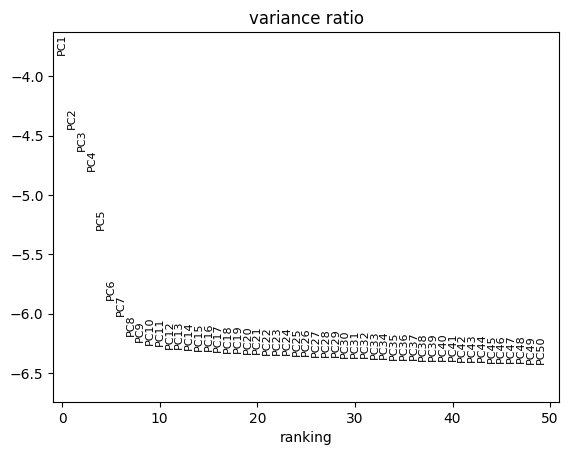

In [118]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

The variance ratio plot shows a clear elbow around PC8-10, confirming that the major sources of biological variation are captured in the first 10 principal components. I retained 50 components to preserve minor cell populations before clustering.

### PCA Results

**Variance ratio plot observations:**
- PC1 explains the most variance by far — it captures the largest 
  source of biological variation in the data
- PC2, PC3, PC4 still contribute significantly
- The curve shows a clear elbow around PC8-10
- After PC10 the curve flattens — each additional component 
  adds very little new information

**How many components to use?**
- We retained 50 components to be safe
- Most biological signal is captured in the first 10-15 components
- Remaining components capture minor variation and some noise

**What this tells us biologically:**
- The data has clear structure — a few components capture most of the biology
- This gives us confidence that distinct cell populations exist in the data
- These 50 components will be used as input for UMAP and clustering

**Key decision:**
Retaining 50 components rather than just 10 ensures we don't accidentally discard signal from rare cell populations that may only appear in 
lower principal components.

## Step 7: Neighborhood Graph

For each cell, we find its 15 most similar cells based on 
distance in PCA space and draw a connection between them.

This creates a network where:
- Connected cells = similar gene expression
- Disconnected cells = different gene expression

This graph is the input for both UMAP and Leiden clustering.

**Key parameters:**
- n_neighbors=15 → each cell connects to its 15 nearest neighbors
- n_pcs=50 → similarity is calculated using all 50 PCA components

In [125]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)

## Step 8: UMAP

UMAP takes the neighborhood graph and compresses it to 2D for visualization. Cells that are similar (connected in the 
graph) get pulled together. Cells that are different get pushed apart.

The result is a 2D map of all 2,638 cells where clusters represent distinct cell populations.

Note: UMAP axes have no biological meaning — only the 
relative positions of cells matter.

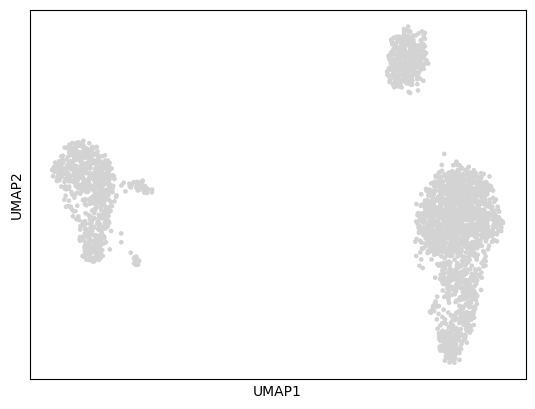

In [130]:
sc.tl.umap(adata)
sc.pl.umap(adata)

UMAP reveals that the 2,638 cells naturally separate into distinct groups based on gene expression similarity. The separation confirms that biologically distinct cell populations exist in this dataset. Colors will be assigned after Leiden clustering.

## Step 9: Leiden Clustering

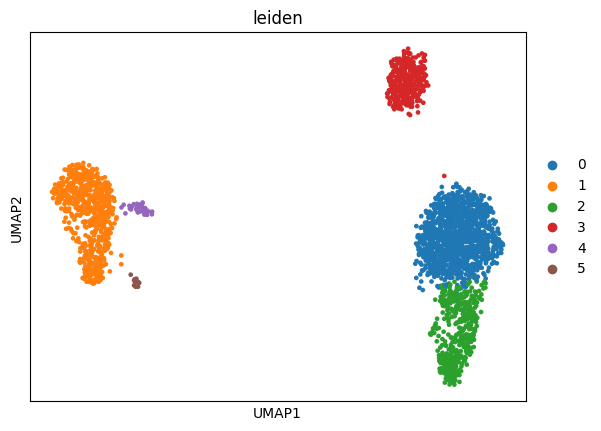

In [134]:
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color='leiden')

UMAP is a 2D projection of a 50-dimensional space. Some cells that appear close on UMAP belong to different clusters because Leiden clustering operates in the full 50D PCA space where their differences are more apparent.

## Step 10: Marker Genes

Now we identify which genes are uniquely expressed in each cluster.
This tells us the biological identity of each cluster.

The question we're asking:
"For each cluster, which genes are significantly higher 
expressed compared to all other clusters?"

These differentially expressed genes are called marker genes.

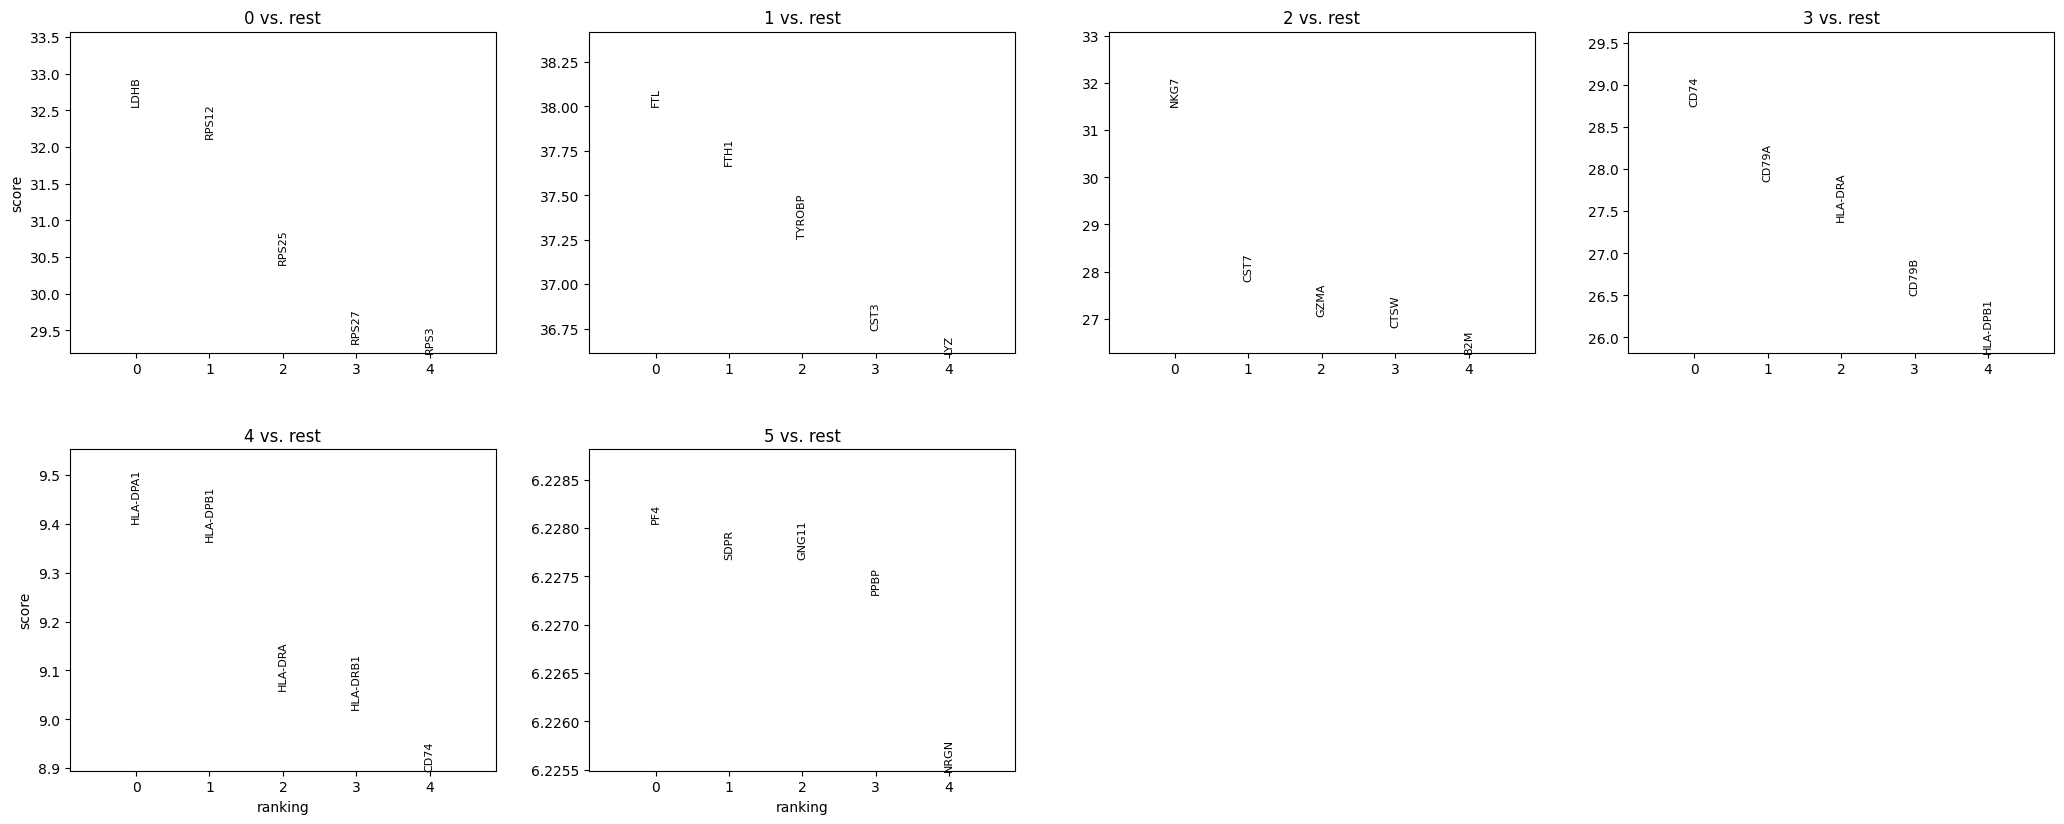

In [138]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

Using the Wilcoxon rank-sum test, I identified the top differentially expressed genes per cluster and matched them to known cell type markers from published literature. All 6 clusters mapped to known PBMC cell populations.

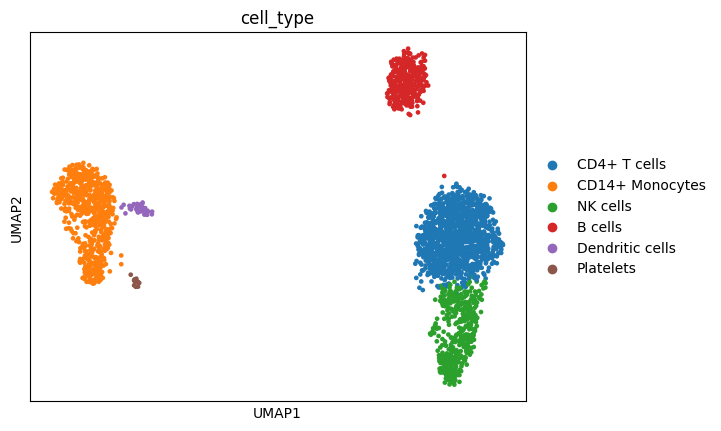

In [141]:
cluster_to_celltype = {
    '0': 'CD4+ T cells',
    '1': 'CD14+ Monocytes',
    '2': 'NK cells',
    '3': 'B cells',
    '4': 'Dendritic cells',
    '5': 'Platelets'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype)
sc.pl.umap(adata, color='cell_type')

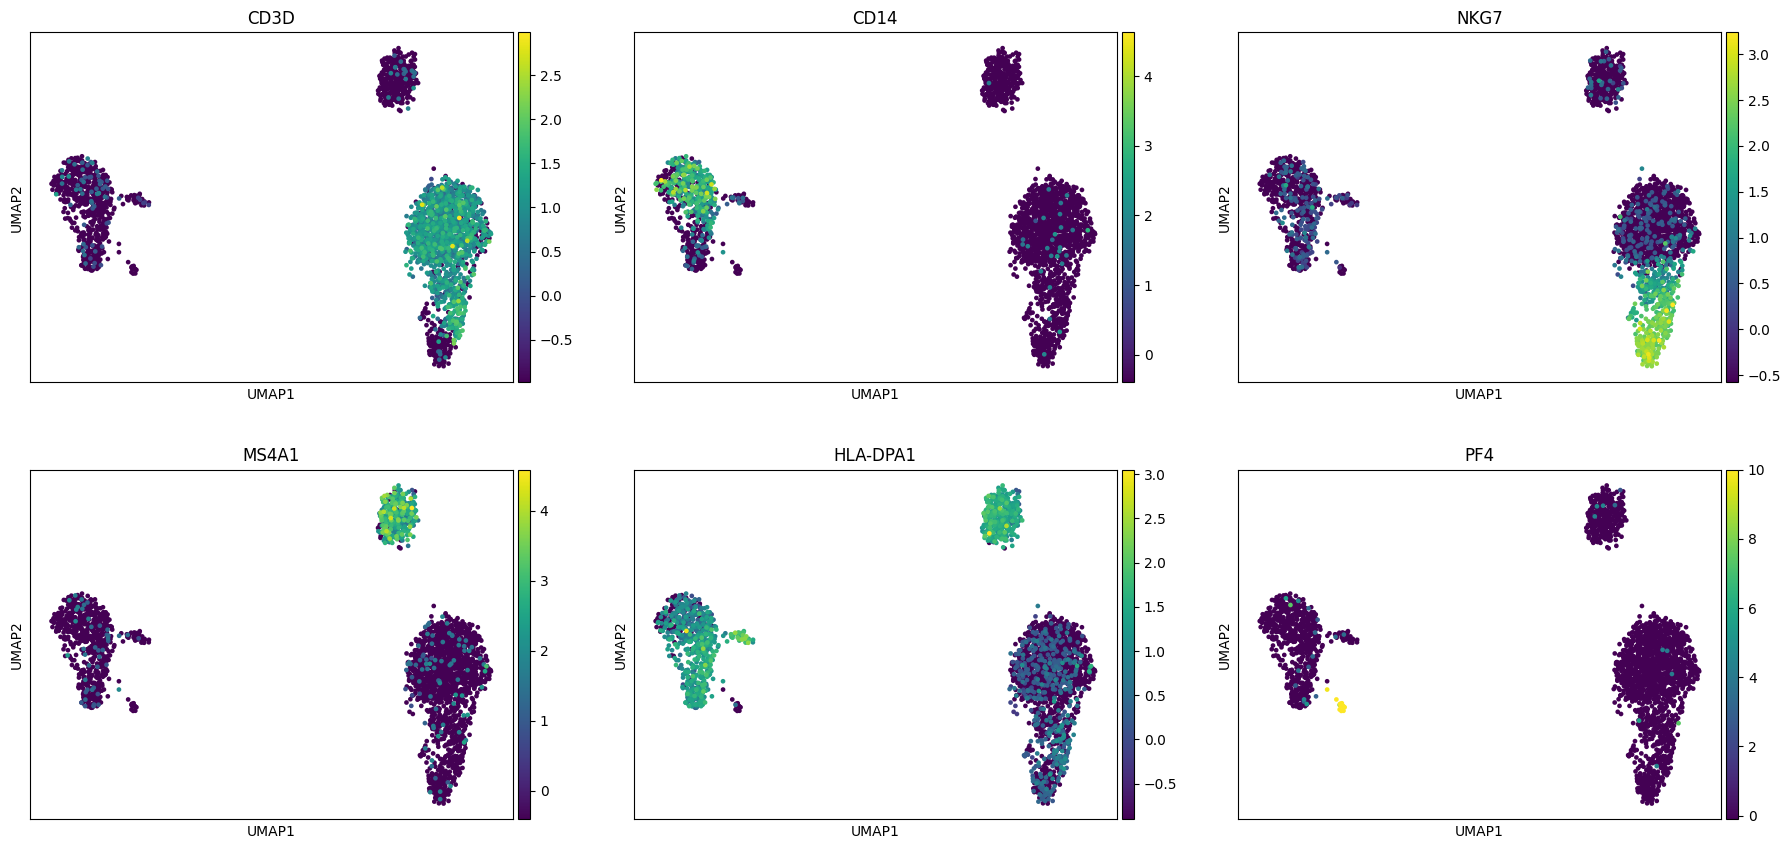

In [143]:
marker_genes = ['CD3D', 'CD14', 'NKG7', 'MS4A1', 'HLA-DPA1', 'PF4']
sc.pl.umap(adata, color=marker_genes, ncols=3)

## Summary

### What we did
Starting with 2,700 unlabeled blood cells and 32,738 genes, I built a complete single-cell RNA sequencing analysis pipeline:

1. **Quality Control** — Removed 62 dead/damaged cells using gene counts, total RNA counts, and mitochondrial percentage
2. **Normalization** — Scaled all cells to 10,000 total counts and log-transformed to make cells comparable
3. **Feature Selection** — Identified 1,838 highly variable genes out of 33,000 for downstream analysis
4. **PCA** — Reduced 1,838 dimensions to 50 principal components, capturing major biological variation while removing noise
5. **Neighborhood Graph** — Connected each cell to its 15 most similar neighbors in PCA space
6. **UMAP** — Projected cells to 2D for visualization
7. **Leiden Clustering** — Identified 6 distinct cell populations
8. **Marker Genes** — Found differentially expressed genes per cluster using Wilcoxon rank-sum test
9. **Cell Type Annotation** — Mapped clusters to known immune cell types using published marker gene databases

### Cell populations identified
| Cluster | Cell Type | Key Marker |
|---------|-----------|------------|
| 0 | CD4+ T cells | LDHB, CD3D |
| 1 | CD14+ Monocytes | FTL, CD14 |
| 2 | NK cells | NKG7, GZMA |
| 3 | B cells | CD74, CD79A |
| 4 | Dendritic cells | HLA-DPA1 |
| 5 | Platelets | PF4 |

### ML techniques used
- Dimensionality reduction (PCA, UMAP)
- Feature selection (highly variable genes)
- Unsupervised clustering (Leiden algorithm)
- Statistical testing (Wilcoxon rank-sum)
- Graph-based methods (k-nearest neighbor graph)

### Limitations
- Cell type annotation was based on top marker genes only — automated tools like CellTypist would provide more robust annotation
- Resolution parameter (0.5) was chosen as a starting point — different resolutions may reveal sub-populations (e.g. CD8+ T cells)
- This is a single timepoint from one donor — results may vary across donors or conditions

### Next steps
- Try different clustering resolutions to find sub-populations
- Use automated cell type annotation tools
- Extend to spatial transcriptomics to map where these cells live in tissue

In [147]:
adata.write('../data/pbmc3k_processed.h5ad')
print("Data saved!")

Data saved!
